# Agente Experto en analizar económicamente el sector de la industria textil y la moda en España
**Stack:** Google Gemini (LLM) · HuggingFace E5 (Embeddings) · ChromaDB · LangGraph · RAG + Memoria  
**Dominio:** Industria textil y moda en España (4 documentos PDF)

---
## PASO 1 — Carga y preprocesamiento de documentos PDF

#### Imports y configuración inicial

In [2]:
import os
import gc
import chromadb
import time
from pathlib import Path
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma                                   # langchain-chroma (sin deprecation warning)
from langchain_community.embeddings import HuggingFaceEmbeddings      # embeddings locales, sin cuotas
from langchain_google_genai import ChatGoogleGenerativeAI             # LLM sigue siendo Gemini
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

In [3]:
load_dotenv(dotenv_path=Path("..") / ".env")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [4]:
DOCS_DIR = Path("..") / "docs"

pdf_files = [
    DOCS_DIR / "informe-economico-de-la-moda-en-espana-2025.pdf",
    DOCS_DIR / "presentaciones_sectoriales_textil.pdf",
    DOCS_DIR / "memoria_anual_inditex_2025.pdf",
    DOCS_DIR / "comercio_textil_2024.pdf",
]

documents = []
for path in pdf_files:
    if not path.exists():
        print(f"⚠ No encontrado: {path}")
        continue
    loader = PyPDFLoader(str(path))
    docs = loader.load()
    documents.extend(docs)
    print(f"✓ {path.name:<55} {len(docs):>3} páginas")

print(f"\nTotal páginas cargadas: {len(documents)}")

✓ informe-economico-de-la-moda-en-espana-2025.pdf         134 páginas
✓ presentaciones_sectoriales_textil.pdf                    36 páginas
✓ memoria_anual_inditex_2025.pdf                           85 páginas
✓ comercio_textil_2024.pdf                                 67 páginas

Total páginas cargadas: 322


##### Chunking con RecursiveCharacterTextSplitter

In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", " ", ""],
    length_function=len,
)

chunks_raw = splitter.split_documents(documents)

# Filtrar portadas, índices y páginas con contenido insuficiente.
# Los chunks muy cortos no aportan información útil al RAG y contaminan los resultados.
MIN_CHUNK_CHARS = 100
chunks = [c for c in chunks_raw if len(c.page_content.strip()) >= MIN_CHUNK_CHARS]

print(f"Total chunks generados:    {len(chunks_raw)}")
print(f"Chunks descartados (<{MIN_CHUNK_CHARS} chars): {len(chunks_raw) - len(chunks)}")
print(f"Chunks útiles:             {len(chunks)}")
print(f"Promedio chars/chunk:      {sum(len(c.page_content) for c in chunks) // len(chunks)}")

print("\n=== Ejemplo chunk #20 ===")
print(f"Fuente: {Path(chunks[20].metadata.get('source', 'N/A')).name} | Página: {chunks[20].metadata.get('page', 'N/A')}")
print(chunks[20].page_content)

Total chunks generados:    681
Chunks descartados (<100 chars): 47
Chunks útiles:             634
Promedio chars/chunk:      781

=== Ejemplo chunk #20 ===
Fuente: informe-economico-de-la-moda-en-espana-2025.pdf | Página: 8
inspirar al mundo desde nuestras fortalezas. 
No se trata solo de resistir, sino de redefinir 
el papel de España en el nuevo mapa global.
Es el momento de actuar con ambición, 
propósito e inteligencia estratégica. Porque, 
si no lideramos nuestro futuro, otros lo 
harán por nosotros.


##### Diagnóstico de modelos disponibles para embeddings

In [6]:
# Esta celda se mantiene como documentación: lista los modelos de embedding disponibles
# en la cuenta y justifica la elección de gemini-embedding-001 para la indexación.
# La librería google.generativeai muestra un FutureWarning (deprecada), pero sigue
# siendo la forma más directa de listar modelos disponibles en la cuenta.
import google.generativeai as genai

genai.configure(api_key=GOOGLE_API_KEY)

print("Modelos de embedding disponibles en tu cuenta:\n")
for m in genai.list_models():
    es_embedding = "embed" in m.name.lower() or (
        m.supported_generation_methods
        and "embed" in m.supported_generation_methods[0].lower()
    )
    if es_embedding:
        print(f"  Nombre: {m.name}")
        print(f"  Métodos: {m.supported_generation_methods}\n")

C:\Users\victor.horcas\AppData\Local\Temp\ipykernel_10740\3839684061.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Modelos de embedding disponibles en tu cuenta:

  Nombre: models/gemini-embedding-001
  Métodos: ['embedContent', 'countTextTokens', 'countTokens', 'asyncBatchEmbedContent']

  Nombre: models/gemini-embedding-2-preview
  Métodos: ['embedContent', 'countTextTokens', 'countTokens', 'asyncBatchEmbedContent']

  Nombre: models/gemini-embedding-2
  Métodos: ['embedContent', 'countTextTokens', 'countTokens', 'asyncBatchEmbedContent']



##### Intento con Google Gemini Embeddings — descartado por cuota del free tier

Se intentó usar `gemini-embedding-001` (el modelo más potente disponible según la celda anterior), pero el **free tier limita a 100 requests/min** y los 681 chunks en lotes de 50 con pausas de 65 s entre lotes siguieron generando errores 429 de forma intermitente e impredecible.

**Decisión:** se usa `intfloat/multilingual-e5-base` de HuggingFace, que corre en local sin cuotas ni API key. Es un modelo diseñado específicamente para tareas de **retrieval** (RAG), con soporte nativo de español y dimensiones de 768 frente a las 384 de MiniLM. Los modelos E5 requieren un prefijo `"passage: "` al indexar y `"query: "` al buscar para obtener su rendimiento óptimo.

In [7]:
EMBEDDING_MODEL = "intfloat/multilingual-e5-base"
CHROMA_DIR      = str(Path("..") / "chroma_db")
COLLECTION_NAME = "textil_moda_espana"

# Los modelos E5 de intfloat requieren prefijos distintos según el uso:
# - "passage: " para los documentos que se indexan en ChromaDB
# - "query: "   para las preguntas del usuario en tiempo de búsqueda
# Sin estos prefijos el modelo funciona, pero rinde por debajo de su capacidad.
class E5MultilingualEmbeddings(HuggingFaceEmbeddings):
    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        return super().embed_documents(["passage: " + t for t in texts])
    def embed_query(self, text: str) -> list[float]:
        return super().embed_query("query: " + text)

# Eliminar colección anterior para evitar duplicados al re-ejecutar
if Path(CHROMA_DIR).exists():
    try:
        _tmp = chromadb.PersistentClient(path=CHROMA_DIR)
        _tmp.delete_collection(COLLECTION_NAME)
        del _tmp
        gc.collect()
        print("✓ Colección anterior eliminada")
    except Exception:
        pass

# El modelo se descarga automáticamente en la primera ejecución (~280 MB).
# Corre en local: sin API key, sin cuotas, sin rate limits.
print(f"Cargando modelo: {EMBEDDING_MODEL}\n")
embeddings = E5MultilingualEmbeddings(
    model_name=EMBEDDING_MODEL,
    encode_kwargs={"normalize_embeddings": True},
)

print(f"Indexando {len(chunks)} chunks en ChromaDB...")
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=CHROMA_DIR,
)

total = vectorstore._collection.count()
print(f"\n✓ Colección '{COLLECTION_NAME}' creada con {EMBEDDING_MODEL}")
print(f"✓ Chunks indexados: {total}")
print(f"✓ Persistido en:    {CHROMA_DIR}")

Cargando modelo: intfloat/multilingual-e5-base



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Indexando 634 chunks en ChromaDB...

✓ Colección 'textil_moda_espana' creada con intfloat/multilingual-e5-base
✓ Chunks indexados: 634
✓ Persistido en:    ..\chroma_db


##### Verificación (consultas de prueba)

In [8]:
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 6, "fetch_k": 20, "lambda_mult": 0.7},
)

test_queries = [
    "¿Cuál es el volumen del sector textil en España?",
    "¿Cuáles son los resultados financieros de Inditex en 2024?",
    "¿Cuál es la posición de España en el sector textil europeo?",
]

for query in test_queries:
    results = retriever.invoke(query)
    print(f"\n{'='*65}")
    print(f"QUERY: {query}")
    print(f"{'='*65}")
    for i, doc in enumerate(results):
        fuente = Path(doc.metadata.get('source', 'N/A')).name
        pagina = doc.metadata.get('page', 'N/A')
        print(f"  [{i+1}] {fuente} | p.{pagina}")
        print(f"      {doc.page_content[:200].strip()}")
        print()

print("✓ Base de conocimiento lista para conectar el agente")


QUERY: ¿Cuál es el volumen del sector textil en España?
  [1] comercio_textil_2024.pdf | p.48
      Evolución​ del Empleo​
de la Industria Textil en España
T extil / Confección 
Nº de trabajadores
136 137
135
129
128
131 131
128
2017 2018 2019 2020 2021 2022 2023 2024

  [2] comercio_textil_2024.pdf | p.52
      Proveedores - Importaciones​
19,2%
15%
10,1%
8%
6,3%
5,8%
5,1%
4,2%
3,7%
3,7%
Países donde más Importa​
la Industria Textil en España​

  [3] comercio_textil_2024.pdf | p.41
      Volumen ​de Negocio eCommerce​
desde España con el Exterior​ por áreas 
Geográficas
II Trimestre 2024

  [4] presentaciones_sectoriales_textil.pdf | p.33
      34
4. COMPARATIVAINTERNACIONAL
4.2. RELEVANCIA DEL SECTOR (I)
Sector de Textil y Confección (2023)
(porcentaje que representa España sobre el total de la UE)
Fuente: elaboración propia, a partir de da

  [5] informe-economico-de-la-moda-en-espana-2025.pdf | p.3
      3
122 PIB
124 Empleo
126 Exportación/Importación
128 Metodología
7
El negocio

---
## PASO 2 — Agente LangGraph con RAG y Memoria

Arquitectura del grafo:
```
START → [nodo_reformular] → [nodo_recuperar] → [nodo_generar] → END
```
- **nodo_reformular**: usa el LLM para reescribir la pregunta con sinónimos del dominio textil antes de buscar
- **nodo_recuperar**: busca los 6 chunks más relevantes en ChromaDB usando MMR (diversidad maximizada)
- **nodo_generar**: llama a Gemini con el system prompt + contexto recuperado + historial completo
- **Memoria**: `MemorySaver` persiste el historial entre turnos usando `thread_id`

### System Prompt
El prompt define el rol, tono y limitaciones del agente. Se inyecta en cada turno junto con el contexto RAG recuperado.

In [9]:
SYSTEM_PROMPT = """Eres un analista experto en la industria textil y moda en España.

Tu conocimiento proviene de los documentos que se te proporcionan como contexto.
Respondes siempre en español, con un tono profesional y conciso.

Reglas:
- Basa tus respuestas en el contexto documental proporcionado.
- Puedes sintetizar y relacionar información de tus respuestas anteriores en la conversación,
  siempre que las afirmaciones originales provengan del contexto documental.
- Si el contexto no contiene información suficiente y no puedes inferirlo del historial, indícalo claramente.
- No inventes datos, cifras ni estadísticas que no aparezcan en el contexto o en el historial previo.
- Cuando cites datos numéricos, menciona la fuente si está disponible en el contexto.
"""

In [19]:
LLM_MODEL = "gemini-1.5-flash"

llm = ChatGoogleGenerativeAI(
    model=LLM_MODEL,
    temperature=0.3,
    google_api_key=GOOGLE_API_KEY,
)

print(f"LLM cargado: {LLM_MODEL}")

LLM cargado: gemini-1.5-flash


gemini-1.5-flash ofrece 1.500 requests/día en el free tier frente a las 20 de gemini-2.5-flash-lite, lo que lo hace viable para desarrollo y pruebas. La calidad de respuesta es muy similar para tareas de análisis documental en español, con baja latencia y coste nulo en el tier gratuito.

#### Estado y nodos del grafo LangGraph

In [11]:
REFORMULATION_PROMPT = """Eres un asistente especializado en documentos sobre la industria textil y moda en España.
Tu tarea es reformular la siguiente pregunta expandiéndola con sinónimos y términos relacionados del sector, \
para mejorar la recuperación de información en una base de conocimiento documental.
Devuelve ÚNICAMENTE la query reformulada en una sola línea, sin explicaciones ni puntuación extra."""

class EstadoAgente(TypedDict):
    mensajes: Annotated[list[BaseMessage], add_messages]
    contexto: str
    query_reformulada: str

def nodo_reformular(estado: EstadoAgente) -> dict:
    """Reescribe la pregunta del usuario con sinónimos del dominio textil para mejorar el RAG."""
    ultima_pregunta = estado["mensajes"][-1].content
    respuesta = llm.invoke([
        SystemMessage(content=REFORMULATION_PROMPT),
        HumanMessage(content=ultima_pregunta),
    ])
    query_expandida = respuesta.content.strip()
    print(f"  [QUERY] Original:    '{ultima_pregunta[:70]}'")
    print(f"  [QUERY] Reformulada: '{query_expandida[:70]}'")
    return {"query_reformulada": query_expandida}

def nodo_recuperar(estado: EstadoAgente) -> dict:
    """Recupera los chunks más relevantes de ChromaDB usando la query reformulada."""
    docs = retriever.invoke(estado["query_reformulada"])
    contexto = "\n\n".join([
        f"[Fuente: {Path(d.metadata.get('source','?')).name} | p.{d.metadata.get('page','?')}]\n{d.page_content}"
        for d in docs
    ])
    print(f"  [RAG]   {len(docs)} chunks recuperados")
    return {"contexto": contexto}

def nodo_generar(estado: EstadoAgente) -> dict:
    """Genera la respuesta usando el LLM con el contexto RAG y el historial."""
    prompt_con_contexto = SYSTEM_PROMPT + f"\n\nCONTEXTO RELEVANTE DE LOS DOCUMENTOS:\n{estado['contexto']}"
    mensajes_completos = [SystemMessage(content=prompt_con_contexto)] + estado["mensajes"]
    respuesta = llm.invoke(mensajes_completos)
    return {"mensajes": [respuesta]}

print("Nodos definidos: nodo_reformular, nodo_recuperar, nodo_generar")

Nodos definidos: nodo_reformular, nodo_recuperar, nodo_generar


#### Construir y compilar el grafo con memoria

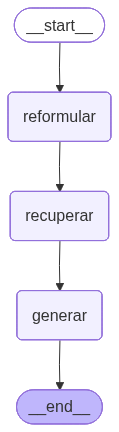


✓ Agente compilado con memoria


In [12]:
grafo = StateGraph(EstadoAgente)

grafo.add_node("reformular", nodo_reformular)
grafo.add_node("recuperar", nodo_recuperar)
grafo.add_node("generar", nodo_generar)

grafo.add_edge(START, "reformular")
grafo.add_edge("reformular", "recuperar")
grafo.add_edge("recuperar", "generar")
grafo.add_edge("generar", END)

memoria = MemorySaver()
agente = grafo.compile(checkpointer=memoria)

# Visualización del grafo
try:
    from IPython.display import Image, display
    display(Image(agente.get_graph().draw_mermaid_png()))
except Exception:
    print(agente.get_graph().draw_ascii())

print("\n✓ Agente compilado con memoria")

---
## PASO 3 — Interacción y ejemplos documentados

In [13]:
# Función de conversación con el agente
def chatear(pregunta: str, thread_id: str = "sesion-01") -> str:
    """Envía una pregunta al agente y devuelve la respuesta."""
    config = {"configurable": {"thread_id": thread_id}}
    resultado = agente.invoke(
        {"mensajes": [HumanMessage(content=pregunta)]},
        config=config,
    )
    return resultado["mensajes"][-1].content

def mostrar_respuesta(pregunta: str, thread_id: str = "sesion-01"):
    """Helper para mostrar pregunta y respuesta con formato."""
    print(f"\n{'='*65}")
    print(f"PREGUNTA: {pregunta}")
    print(f"{'='*65}")
    respuesta = chatear(pregunta, thread_id)
    print(f"\nRESPUESTA:\n{respuesta}")
    return respuesta

print("✓ Funciones de conversación listas")

✓ Funciones de conversación listas


#### 5 ejemplos documentados (mismo thread para demostrar memoria)

In [14]:
THREAD = "demo-ejemplos"

# Ejemplo 1
mostrar_respuesta("¿Cuántas empresas textiles hay en España y cómo ha evolucionado este número?", THREAD)


PREGUNTA: ¿Cuántas empresas textiles hay en España y cómo ha evolucionado este número?
  [QUERY] Original:    '¿Cuántas empresas textiles hay en España y cómo ha evolucionado este n'
  [QUERY] Reformulada: '¿Cuál es el censo de compañías del sector de la confección y moda en e'
  [RAG]   6 chunks recuperados

RESPUESTA:
Según la información proporcionada:

En 2024, el número de empresas dedicadas a la industria de la confección en España se ajusta hasta **7.842 sociedades**.

La evolución anual del número de empresas de confección entre 2015 y 2024 ha sido la siguiente (variación en porcentaje):
*   2015: 0,2%
*   2016: -1,0%
*   2017: 2,3%
*   2018: 2,8%
*   2019: 2,0%
*   2020: -11,2%
*   2021: -2,7%
*   2022: -0,1%
*   2023: 0,2%
*   2024: 2,7% (se indica que tras una caída a doble dígito en el ejercicio precedente, el número se ajusta en 2024).

La fuente de estos datos es el INE (Instituto Nacional de Estadística).


'Según la información proporcionada:\n\nEn 2024, el número de empresas dedicadas a la industria de la confección en España se ajusta hasta **7.842 sociedades**.\n\nLa evolución anual del número de empresas de confección entre 2015 y 2024 ha sido la siguiente (variación en porcentaje):\n*   2015: 0,2%\n*   2016: -1,0%\n*   2017: 2,3%\n*   2018: 2,8%\n*   2019: 2,0%\n*   2020: -11,2%\n*   2021: -2,7%\n*   2022: -0,1%\n*   2023: 0,2%\n*   2024: 2,7% (se indica que tras una caída a doble dígito en el ejercicio precedente, el número se ajusta en 2024).\n\nLa fuente de estos datos es el INE (Instituto Nacional de Estadística).'

In [15]:
# Ejemplo 2
mostrar_respuesta("¿Cuáles son los principales resultados financieros de Inditex en 2024?", THREAD)


PREGUNTA: ¿Cuáles son los principales resultados financieros de Inditex en 2024?
  [QUERY] Original:    '¿Cuáles son los principales resultados financieros de Inditex en 2024?'
  [QUERY] Reformulada: '¿Cuáles son los principales indicadores económicos y de rentabilidad d'
  [RAG]   6 chunks recuperados

RESPUESTA:
Los principales resultados financieros de Inditex en 2024, según la información proporcionada, son los siguientes:

**Activos Financieros:**

*   **Efectivo y equivalentes:** 5.276 millones de euros.
*   **Inversiones financieras temporales:** 5.684 millones de euros.
*   **Deudores comerciales:** 439 millones de euros.
*   **Deudores por ventas a franquicias:** 349 millones de euros.
*   **Otros deudores corrientes:** 125 millones de euros.
*   **Fianzas:** 154 millones de euros.
*   **Total activos financieros:** 12.027 millones de euros.

**Pasivos Financieros:**

*   Los principales pasivos financieros corresponden a débitos y cuentas a pagar en concepto de operaciones c

'Los principales resultados financieros de Inditex en 2024, según la información proporcionada, son los siguientes:\n\n**Activos Financieros:**\n\n*   **Efectivo y equivalentes:** 5.276 millones de euros.\n*   **Inversiones financieras temporales:** 5.684 millones de euros.\n*   **Deudores comerciales:** 439 millones de euros.\n*   **Deudores por ventas a franquicias:** 349 millones de euros.\n*   **Otros deudores corrientes:** 125 millones de euros.\n*   **Fianzas:** 154 millones de euros.\n*   **Total activos financieros:** 12.027 millones de euros.\n\n**Pasivos Financieros:**\n\n*   Los principales pasivos financieros corresponden a débitos y cuentas a pagar en concepto de operaciones comerciales.\n\n**Deterioro de Activos Financieros:**\n\n*   No se ha registrado ningún importe significativo por el deterioro de activos financieros en 2024.\n\nEs importante notar que estos datos corresponden a los activos y pasivos financieros del Grupo Inditex y se presentan en comparación con el e

In [16]:
# Ejemplo 3
mostrar_respuesta("¿Cuál es la posición de España en el sector textil europeo y cuáles son sus principales mercados de exportación?", THREAD)


PREGUNTA: ¿Cuál es la posición de España en el sector textil europeo y cuáles son sus principales mercados de exportación?
  [QUERY] Original:    '¿Cuál es la posición de España en el sector textil europeo y cuáles so'
  [QUERY] Reformulada: '¿Cuál es la relevancia y el posicionamiento de España dentro de la ind'
  [RAG]   6 chunks recuperados

RESPUESTA:
En cuanto a la posición de España en el sector textil europeo, el contexto proporcionado indica que el sector de Textil y Confección en España representa un porcentaje sobre el total de la UE, aunque no se especifica la cifra exacta en el fragmento de la página 33 de "presentaciones_sectoriales_textil.pdf".

Respecto a los principales mercados de exportación de la industria textil en España, los países donde más se exporta son:

*   **Francia:** 14,9%
*   **Portugal:** 13,3%
*   **Italia:** 9,7%
*   **Alemania:** 9,7%
*   **Reino Unido:** 8,3%
*   **Estados Unidos:** 8,1%
*   **Marruecos:** 4,2%
*   **Países Bajos:** 3,3%
*   **Bélgi

'En cuanto a la posición de España en el sector textil europeo, el contexto proporcionado indica que el sector de Textil y Confección en España representa un porcentaje sobre el total de la UE, aunque no se especifica la cifra exacta en el fragmento de la página 33 de "presentaciones_sectoriales_textil.pdf".\n\nRespecto a los principales mercados de exportación de la industria textil en España, los países donde más se exporta son:\n\n*   **Francia:** 14,9%\n*   **Portugal:** 13,3%\n*   **Italia:** 9,7%\n*   **Alemania:** 9,7%\n*   **Reino Unido:** 8,3%\n*   **Estados Unidos:** 8,1%\n*   **Marruecos:** 4,2%\n*   **Países Bajos:** 3,3%\n*   **Bélgica:** 2,5%\n*   **Turquía:** 2,4%\n\nEsta información se extrae de la página 50 de "comercio_textil_2024.pdf".'

In [17]:
# Ejemplo 4 — referencia al contexto de preguntas anteriores (demuestra memoria)
mostrar_respuesta("¿Y qué papel juega Inditex en esas exportaciones de moda española que acabas de mencionar?", THREAD)


PREGUNTA: ¿Y qué papel juega Inditex en esas exportaciones de moda española que acabas de mencionar?
  [QUERY] Original:    '¿Y qué papel juega Inditex en esas exportaciones de moda española que '
  [QUERY] Reformulada: '¿Cuál es la contribución de Inditex al volumen de exportación de la in'
  [RAG]   6 chunks recuperados

RESPUESTA:
El contexto proporcionado menciona que Industria de Diseño Textil, S.A. (Inditex) tiene su domicilio en España y sus acciones cotizan en las bolsas de valores españolas. Su actividad principal consiste en ofrecer moda a través de diversos formatos comerciales como Zara, Pull&Bear, Massimo Dutti, Bershka, Stradivarius, Oysho, Lefties y Zara Home. Cada uno de estos formatos opera con un modelo de tiendas y venta online.

Sin embargo, el contexto **no especifica el porcentaje o el papel concreto que Inditex juega en las exportaciones totales de moda española** mencionadas anteriormente. Solo se describe la estructura y actividad del grupo.


'El contexto proporcionado menciona que Industria de Diseño Textil, S.A. (Inditex) tiene su domicilio en España y sus acciones cotizan en las bolsas de valores españolas. Su actividad principal consiste en ofrecer moda a través de diversos formatos comerciales como Zara, Pull&Bear, Massimo Dutti, Bershka, Stradivarius, Oysho, Lefties y Zara Home. Cada uno de estos formatos opera con un modelo de tiendas y venta online.\n\nSin embargo, el contexto **no especifica el porcentaje o el papel concreto que Inditex juega en las exportaciones totales de moda española** mencionadas anteriormente. Solo se describe la estructura y actividad del grupo.'

In [18]:
# Ejemplo 5
mostrar_respuesta("¿Cuál es la balanza comercial del sector textil en España y qué tendencia muestra?", THREAD)


PREGUNTA: ¿Cuál es la balanza comercial del sector textil en España y qué tendencia muestra?
  [QUERY] Original:    '¿Cuál es la balanza comercial del sector textil en España y qué tenden'
  [QUERY] Reformulada: '¿Cuál es el saldo de la balanza comercial de la industria de la confec'
  [RAG]   6 chunks recuperados

RESPUESTA:
La balanza comercial del sector textil en España presenta un déficit. En 2023, el déficit fue de **-13.484 millones de euros**.

La tendencia de esta balanza comercial ha sido la siguiente:

*   **2017:** -10.153 millones de euros
*   **2018:** -12.191 millones de euros
*   **2019:** -12.757 millones de euros
*   **2020:** -10.153 millones de euros (cifra idéntica a 2017, lo que podría indicar una anomalía o un error en la transcripción del dato)
*   **2021:** -12.997 millones de euros
*   **2022:** -14.739 millones de euros
*   **2023:** -13.484 millones de euros

Se observa una tendencia general de aumento del déficit comercial hasta 2022, con una ligera reducc

'La balanza comercial del sector textil en España presenta un déficit. En 2023, el déficit fue de **-13.484 millones de euros**.\n\nLa tendencia de esta balanza comercial ha sido la siguiente:\n\n*   **2017:** -10.153 millones de euros\n*   **2018:** -12.191 millones de euros\n*   **2019:** -12.757 millones de euros\n*   **2020:** -10.153 millones de euros (cifra idéntica a 2017, lo que podría indicar una anomalía o un error en la transcripción del dato)\n*   **2021:** -12.997 millones de euros\n*   **2022:** -14.739 millones de euros\n*   **2023:** -13.484 millones de euros\n\nSe observa una tendencia general de aumento del déficit comercial hasta 2022, con una ligera reducción en 2023.\n\nEstos datos provienen de la página 49 del documento "comercio_textil_2024.pdf".'

---
## PASO 4 — Chat interactivo

Celda de conversación libre con el agente. Ejecuta y escribe tu pregunta cuando aparezca el prompt.

In [17]:
# Celda interactiva — escribe 'salir' para terminar
THREAD_CHAT = "chat-interactivo"
print("Agente Textil España — escribe 'salir' para terminar\n")

while True:
    pregunta = input("Tú: ").strip()
    if not pregunta:
        continue
    if pregunta.lower() in ("salir", "exit", "quit"):
        print("Conversación finalizada.")
        break
    respuesta = chatear(pregunta, THREAD_CHAT)
    print(f"\nAgente: {respuesta}\n")

Agente Textil España — escribe 'salir' para terminar

Conversación finalizada.
